# DualSleep — LOSO SVM Pipeline

This notebook:
1) Loads raw CSVs from Google Drive  
2) Builds compact **Parquet** files (raw and 60-second windows)  
3) Assembles the feature matrix  
4) Trains **RBF-SVM** with **Leave-One-Subject-Out (LOSO)**  
5) Saves baseline + final (threshold-tuned) results and plots

> Re-running after a restart: you only need Sections **1 → 2 → 3 → 6 → 8 → 9 → 10 → 11** (skip rebuilds if Parquet exists).

## 1) Environment Setup and Imports

We start by preparing the Colab environment and loading all necessary libraries.

- **Mount Google Drive:** Allows direct access to project datasets and saves under `/content/drive/`.
- **Core Libraries:**
  - **pandas / numpy** — data manipulation and numerical processing  
  - **matplotlib** — quick visualizations and diagnostics  
  - **pyarrow** — reading and writing Parquet files efficiently  
  - **scipy.stats** — statistical feature functions (e.g., skewness, kurtosis)  
  - **scikit-learn** — model pipelines, SVMs, scaling, grid search, and evaluation metrics  

We also apply basic display settings for better readability and suppress unnecessary warnings.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyarrow import parquet as pq
from pathlib import Path
from datetime import datetime

from scipy.stats import skew, kurtosis
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import GridSearchCV, HalvingGridSearchCV
from sklearn.metrics import confusion_matrix, f1_score, balanced_accuracy_score, make_scorer, classification_report
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 120)
plt.rcParams['figure.dpi'] = 110
warnings.filterwarnings("ignore", category=FutureWarning)

Mounted at /content/drive


## 2) Locate data on Drive and list raw CSVs

We’ll work inside the `dualsleep` folder on Drive and list all input CSV files.

In [ ]:
ROOT = Path('/content/drive/MyDrive/dualsleep')
assert ROOT.exists(), f"Path not found: {ROOT}"

CSV_FILES = sorted(ROOT.glob('*.csv'))
print(f"Found {len(CSV_FILES)} CSV files")
print(CSV_FILES[:3])

Found 29 CSV files
[PosixPath('/content/drive/MyDrive/dualsleep/PSGO_01.csv'), PosixPath('/content/drive/MyDrive/dualsleep/PSGO_02.csv'), PosixPath('/content/drive/MyDrive/dualsleep/PSGO_03.csv')]


## 3) Label Mapping

We map raw label codes → readable labels and create a **binary target**:
- `y = 1` → sleep (any NREM/REM)
- `y = 0` → wake

In [ ]:
# Label dictionary (raw code -> string)
dualsleep_labels = {
    81: "wake",
    82: "non-rem1",
    83: "non-rem2",
    84: "non-rem3",
    85: "rem",
    86: "movement"
}

# Columns to read from CSV and compact dtypes to save memory
usecols = ["timestamp",
           "back_x","back_y","back_z",
           "thigh_x","thigh_y","thigh_z",
           "back_temp","thigh_temp",
           "label"]

dtypes = {
    "back_x":"float32","back_y":"float32","back_z":"float32",
    "thigh_x":"float32","thigh_y":"float32","thigh_z":"float32",
    "back_temp":"float32","thigh_temp":"float32",
    "label":"int8",
}

## 4) CSV → Per-Subject Parquet (compact)

Reads each subject CSV, adds `subject_id`, maps `activity` and binary `y`,
sorts by time, and writes **one Parquet per subject** to `processed_parquet_raw/`.

**Why Parquet?** Fast, compressed, columnar format → much faster reloads than CSV.

In [ ]:
RAW_DIR = ROOT / "processed_parquet_raw"
RAW_DIR.mkdir(exist_ok=True)

# Only build RAW if folder is empty (skip if already present)
if not any(RAW_DIR.glob('*.parquet')):
    for f in CSV_FILES:
        print("Processing:", f.name)
        df = pd.read_csv(
            f,
            usecols=usecols,
            dtype=dtypes,
            parse_dates=["timestamp"],
            engine="c",
            low_memory=False,
            memory_map=True
        )
        # subject id = file stem, activity label and binary y
        df["subject_id"] = f.stem
        df["activity"] = df["label"].map(dualsleep_labels).astype("category")
        df["y"] = df["activity"].isin(["non-rem1","non-rem2","non-rem3","rem"]).astype("int8")
        df.sort_values(["subject_id","timestamp"], inplace=True)
        df.to_parquet(RAW_DIR / f"{f.stem}.parquet", index=False)
        del df
        gc.collect()
    print("Done writing RAW parquet to:", RAW_DIR)
else:
    print("RAW parquet already present:", len(list(RAW_DIR.glob('*.parquet'))))

## 5) Load existing Parquet (raw preview)

Confirm the raw Parquets exist and preview one.

In [ ]:
# Define the folders where processed parquet files are stored
RAW_DIR = ROOT / "processed_parquet_raw"
WIN_DIR = ROOT / "processed_parquet_win60"  # will be built in step 7
pq_files_raw = sorted(RAW_DIR.glob("*.parquet"))

print("RAW subjects:", len(pq_files_raw))
if pq_files_raw:
    display(pd.read_parquet(pq_files_raw[0]).head())

RAW subjects: 29


,timestamp,back_x,back_y,back_z,thigh_x,thigh_y,thigh_z,back_temp,thigh_temp,label,subject_id,activity,y
0,2018-08-31 19:57:30.009,-0.089241,-0.137339,0.937863,0.050926,0.077980,-0.964283,32.813679,29.519478,81,PSGO_01,wake,0
1,2018-08-31 19:57:30.029,-0.094394,-0.181080,0.936325,0.025775,0.157702,-0.972833,32.445202,28.866642,81,PSGO_01,wake,0
2,2018-08-31 19:57:30.049,-0.093680,-0.166980,0.939467,0.034335,0.131260,-0.976096,32.563709,29.084246,81,PSGO_01,wake,0
3,2018-08-31 19:57:30.069,-0.093625,-0.175065,0.929466,0.029103,0.146957,-0.975961,32.496784,28.953690,81,PSGO_01,wake,0
4,2018-08-31 19:57:30.089,-0.093964,-0.169637,0.930173,0.032900,0.135894,-0.970384,32.539471,29.046940,81,PSGO_01,wake,0


Activity counts across all subjects:


,count
activity,
non-rem2,17021994
wake,14944410
rem,7964993
non-rem3,7904996
non-rem1,2884497
movement,6000


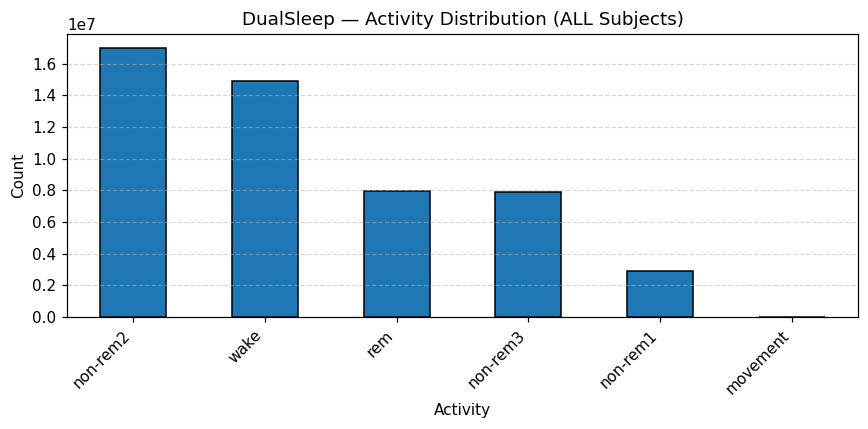

In [ ]:
# Aggregate activity counts across all subjects (memory-safe one file at a time)
activity_counts = pd.Series(dtype='int64')
for p in pq_files_raw:
    df = pd.read_parquet(p, columns=['activity'])
    activity_counts = activity_counts.add(df['activity'].value_counts(), fill_value=0)
    del df
    gc.collect()

activity_counts = activity_counts.astype(int).sort_values(ascending=False)
print("Activity counts across all subjects:")
display(activity_counts.to_frame("count"))

plt.figure(figsize=(8,4))
activity_counts.plot(kind='bar', edgecolor='black')
plt.title("DualSleep — Activity Distribution (ALL Subjects)")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=.5)
plt.tight_layout()
plt.show()

## 6) Build 60-second windows with features (`processed_parquet_win60/`)

We process all raw sensor data into **per-minute feature windows**, computing:
- Statistical summaries (mean, std, min, max, quantiles)
- Signal shape metrics (skewness, kurtosis, energy)
- Magnitude and motion correlations between back and thigh sensors
- cyclic time features (hour, day, month in sine/cosine form)

This step transforms continuous IMU and temperature data into a compact  learning-ready representation for SVM modeling.

In [ ]:
WIN_DIR = ROOT / "processed_parquet_win60"
WIN_DIR.mkdir(exist_ok=True)

cols_acc = ["back_x","back_y","back_z","thigh_x","thigh_y","thigh_z"]
cols_temp = ["back_temp","thigh_temp"]

def to_windows_60s(df):
    """Aggregate raw samples to 60s windows and compute features."""
    df["minute"] = df["timestamp"].dt.floor("60s")
    g = df.groupby("minute", sort=True)

    out = pd.DataFrame(index=g.size().index)
    out["subject_id"] = df["subject_id"].iat[0]

    # Majority vote (most samples in the minute)
    out["y"] = g["y"].mean().round().astype("int8")

    # Per-signal statistics
    for c in cols_acc + cols_temp:
        s = g[c]
        out[f"{c}_mean"] = s.mean()
        out[f"{c}_std"] = s.std(ddof=0)
        out[f"{c}_min"] = s.min()
        out[f"{c}_max"] = s.max()
        out[f"{c}_p25"] = s.quantile(0.25)
        out[f"{c}_p75"] = s.quantile(0.75)

        # safe skew/kurt (return 0 when too few or constant)
        def _skew_safe(x):
            if len(x) < 4 or np.allclose(x, x[0]): return 0.0
            return float(skew(x, bias=False))
        def _kurt_safe(x):
            if len(x) < 4 or np.allclose(x, x[0]): return 0.0
            return float(kurtosis(x, fisher=True, bias=False))
        out[f"{c}_skew"] = s.apply(_skew_safe)
        out[f"{c}_kurt"] = s.apply(_kurt_safe)
        out[f"{c}_energy"] = s.apply(lambda x: float(np.square(x).sum()))

    # Magnitudes
    df["back_mag"] = np.sqrt(df["back_x"]**2  + df["back_y"]**2  + df["back_z"]**2)
    df["thigh_mag"] = np.sqrt(df["thigh_x"]**2 + df["thigh_y"]**2 + df["thigh_z"]**2)
    out["back_mag_mean"] = g["back_mag"].mean()
    out["thigh_mag_mean"] = g["thigh_mag"].mean()

    # Correlations
    def _corr_or_zero(a, b):
        if len(a) > 3:
            return float(np.corrcoef(a, b)[0,1])
        return 0.0
    out["back_thigh_corr_mag"] = g.apply(lambda x: _corr_or_zero(x["back_mag"], x["thigh_mag"]), include_groups=False)
    for axis in ["x","y","z"]:
        out[f"corr_back_{axis}_thigh_{axis}"] = g.apply(
            lambda x, ax=axis: _corr_or_zero(x[f"back_{ax}"], x[f"thigh_{ax}"]),
            include_groups=False
        )

    # Cyclic time (hour/day-of-week/month)
    t = out.index
    hour = t.hour + t.minute/60.0
    day = t.dayofweek + hour/24.0
    monthp = t.month - 1 + (t.day - 1)/30.0

    out["hour_sin"] = np.sin(2*np.pi*hour/24)
    out["hour_cos"] = np.cos(2*np.pi*hour/24)
    out["dow_sin"] = np.sin(2*np.pi*day/7)
    out["dow_cos"] = np.cos(2*np.pi*day/7)
    out["mon_sin"] = np.sin(2*np.pi*monthp/12)
    out["mon_cos"] = np.cos(2*np.pi*monthp/12)

    return out.reset_index().rename(columns={"minute":"timestamp"})

# Build per-subject win60 parquet (skip existing)
raw_files = sorted(RAW_DIR.glob('*.parquet'))
built = 0
for p in raw_files:
    out_p = WIN_DIR / p.name
    if out_p.exists():
        continue
    sdf = pd.read_parquet(p)
    win = to_windows_60s(sdf)
    win.to_parquet(out_p, index=False)
    built += 1
    del sdf, win
    gc.collect()

print(f"WIN parquet ready at {WIN_DIR} (built {built}, total {len(list(WIN_DIR.glob('*.parquet')))})")

## 7) Assemble Feature Matrix

- `feature_cols` = all columns except metadata (`timestamp`, `subject_id`, `y`)  
- Concatenate all per-minute Parquet files into one DataFrame `win60` for modeling.

In [ ]:
WIN_DIR = ROOT / "processed_parquet_win60"
win_files = sorted(WIN_DIR.glob('*.parquet'))
assert win_files, "No WIN parquet files found."

# Peek one file, then concatenate all
preview = pd.read_parquet(win_files[0])
display(preview.head())
display(preview.shape)

# Everything except metadata is a feature
feature_exclude = {"timestamp", "subject_id", "y"}
feature_cols = [c for c in preview.columns if c not in feature_exclude]
print("Num feature columns:", len(feature_cols))

# Load all subjects
win60 = pd.concat([pd.read_parquet(p) for p in win_files], ignore_index=True)
print("win60 shape:", win60.shape)
display(win60.head())

# Optional class balance check
print(win60["y"].value_counts().rename({0:"wake",1:"sleep"}))
print("Subjects:", win60["subject_id"].nunique())
display(win60.groupby("subject_id")["y"].value_counts().unstack(fill_value=0).head())

,timestamp,subject_id,y,back_x_mean,back_x_std,back_x_min,back_x_max,back_x_p25,back_x_p75,back_x_skew,back_x_kurt,back_x_energy,back_y_mean,back_y_std,back_y_min,back_y_max,back_y_p25,back_y_p75,back_y_skew,back_y_kurt,back_y_energy,back_z_mean,back_z_std,back_z_min,back_z_max,back_z_p25,back_z_p75,back_z_skew,back_z_kurt,back_z_energy,thigh_x_mean,thigh_x_std,thigh_x_min,thigh_x_max,thigh_x_p25,thigh_x_p75,thigh_x_skew,thigh_x_kurt,thigh_x_energy,thigh_y_mean,thigh_y_std,thigh_y_min,thigh_y_max,thigh_y_p25,thigh_y_p75,thigh_y_skew,thigh_y_kurt,thigh_y_energy,thigh_z_mean,thigh_z_std,thigh_z_min,thigh_z_max,thigh_z_p25,thigh_z_p75,thigh_z_skew,thigh_z_kurt,thigh_z_energy,back_temp_mean,back_temp_std,back_temp_min,back_temp_max,back_temp_p25,back_temp_p75,back_temp_skew,back_temp_kurt,back_temp_energy,thigh_temp_mean,thigh_temp_std,thigh_temp_min,thigh_temp_max,thigh_temp_p25,thigh_temp_p75,thigh_temp_skew,thigh_temp_kurt,thigh_temp_energy,back_mag_mean,thigh_mag_mean,back_thigh_corr_mag,corr_back_x_thigh_x,corr_back_y_thigh_y,corr_back_z_thigh_z,hour_sin,hour_cos,dow_sin,dow_cos,mon_sin,mon_cos
0,2018-08-31 19:57:00,PSGO_01,0,-0.093380,0.002034,-0.101765,-0.084010,-0.094012,-0.093408,1.757684,7.233584,13.085835,-0.171303,0.002485,-0.181080,-0.137339,-0.172281,-0.171210,3.081703,26.341650,44.026360,0.932911,0.004434,0.919441,0.942562,0.929606,0.936715,-0.150423,-0.656305,1305.514771,0.031085,0.001885,0.016464,0.050926,0.031071,0.031408,-1.187793,31.456001,1.454792,0.140761,0.002191,0.077980,0.157702,0.140507,0.140756,-14.624904,453.992065,29.727806,-0.975634,0.005972,-0.990527,-0.962376,-0.979849,-0.970866,-0.090914,-0.835446,1427.844971,32.440716,0.226722,31.878866,32.877995,32.231832,32.523511,-0.498379,0.029795,1578677.25,29.007019,0.014111,28.866642,29.519478,29.006528,29.006950,31.389986,1167.946655,1262111.00,0.953100,0.986230,0.038584,0.025744,-0.285477,-0.034581,-0.872496,0.488621,-0.930189,-0.367081,-0.866025,-0.5
1,2018-08-31 19:58:00,PSGO_01,0,-0.093182,0.002544,-0.103499,-0.075532,-0.094098,-0.093178,1.623879,6.081160,26.068123,-0.171062,0.002574,-0.179486,-0.156493,-0.172280,-0.171021,1.736475,3.136621,87.807007,0.932849,0.004442,0.917950,0.946709,0.929582,0.936647,-0.080400,-0.570649,2610.683594,0.031163,0.001515,0.011641,0.047497,0.031106,0.031389,-2.538939,41.716774,2.920336,0.140929,0.001810,0.126452,0.158571,0.140478,0.140824,4.176419,28.727755,59.592968,-0.974716,0.005850,-0.989781,-0.962472,-0.978716,-0.969586,-0.334521,-0.718525,2850.317139,32.429150,0.288968,31.561827,32.894321,32.231133,32.523656,-1.071656,1.174702,3155199.75,29.006739,0.000056,29.006638,29.006842,29.006693,29.006786,0.000000,0.000000,2524172.75,0.952978,0.985348,0.025886,0.007804,0.012342,-0.026051,-0.870356,0.492424,-0.930418,-0.366501,-0.866025,-0.5
2,2018-08-31 19:59:00,PSGO_01,0,-0.093608,0.002469,-0.108295,-0.079264,-0.094231,-0.093212,0.261700,5.634394,26.305595,-0.170965,0.002646,-0.181582,-0.160083,-0.172301,-0.170946,1.619027,2.356256,87.707893,0.932118,0.004456,0.916181,0.947701,0.929185,0.935231,-0.032517,-0.321001,2606.589355,0.031248,0.001187,0.016398,0.044936,0.031157,0.031343,-0.357570,47.412865,2.933519,0.141173,0.002250,0.134993,0.158737,0.140441,0.140930,3.704642,16.711273,59.805016,-0.973689,0.005572,-0.989666,-0.960920,-0.977409,-0.969002,-0.495606,-0.499529,2844.301758,32.594517,0.215962,31.895885,32.855755,32.521655,32.815056,-0.722546,0.144428,3187347.50,29.006739,0.000015,29.006712,29.006765,29.006725,29.006752,0.000000,0.000000,2524172.75,0.952286,0.984369,0.002213,-0.004638,0.001883,-0.001214,-0.868199,0.496217,-0.930646,-0.365921,-0.866025,-0.5
3,2018-08-31 20:00:00,PSGO_01,0,-0.095134,0.003674,-0.110250,-0.076992,-0.096426,-0.093376,-0.558349,2.817246,27.191967,-0.171354,0.002366,-0.180146,-0.157254,-0.172234,-0.171329,1.567866,5.204155,88.103264,0.931057,0.004510,0.916323,0.946888,0.927927,0.933988,0.063452,-0.179722,2600.662598,0.031373,0.001653,0.014902,0.051685,0.031137,0.031377,3.099495,40.519714,2.96103

(630, 87)

Num feature columns: 84
win60 shape: (33852, 87)


,timestamp,subject_id,y,back_x_mean,back_x_std,back_x_min,back_x_max,back_x_p25,back_x_p75,back_x_skew,back_x_kurt,back_x_energy,back_y_mean,back_y_std,back_y_min,back_y_max,back_y_p25,back_y_p75,back_y_skew,back_y_kurt,back_y_energy,back_z_mean,back_z_std,back_z_min,back_z_max,back_z_p25,back_z_p75,back_z_skew,back_z_kurt,back_z_energy,thigh_x_mean,thigh_x_std,thigh_x_min,thigh_x_max,thigh_x_p25,thigh_x_p75,thigh_x_skew,thigh_x_kurt,thigh_x_energy,thigh_y_mean,thigh_y_std,thigh_y_min,thigh_y_max,thigh_y_p25,thigh_y_p75,thigh_y_skew,thigh_y_kurt,thigh_y_energy,thigh_z_mean,thigh_z_std,thigh_z_min,thigh_z_max,thigh_z_p25,thigh_z_p75,thigh_z_skew,thigh_z_kurt,thigh_z_energy,back_temp_mean,back_temp_std,back_temp_min,back_temp_max,back_temp_p25,back_temp_p75,back_temp_skew,back_temp_kurt,back_temp_energy,thigh_temp_mean,thigh_temp_std,thigh_temp_min,thigh_temp_max,thigh_temp_p25,thigh_temp_p75,thigh_temp_skew,thigh_temp_kurt,thigh_temp_energy,back_mag_mean,thigh_mag_mean,back_thigh_corr_mag,corr_back_x_thigh_x,corr_back_y_thigh_y,corr_back_z_thigh_z,hour_sin,hour_cos,dow_sin,dow_cos,mon_sin,mon_cos
0,2018-08-31 19:57:00,PSGO_01,0,-0.093380,0.002034,-0.101765,-0.084010,-0.094012,-0.093408,1.757684,7.233584,13.085835,-0.171303,0.002485,-0.181080,-0.137339,-0.172281,-0.171210,3.081703,26.341650,44.026360,0.932911,0.004434,0.919441,0.942562,0.929606,0.936715,-0.150423,-0.656305,1305.514771,0.031085,0.001885,0.016464,0.050926,0.031071,0.031408,-1.187793,31.456001,1.454792,0.140761,0.002191,0.077980,0.157702,0.140507,0.140756,-14.624904,453.992065,29.727806,-0.975634,0.005972,-0.990527,-0.962376,-0.979849,-0.970866,-0.090914,-0.835446,1427.844971,32.440716,0.226722,31.878866,32.877995,32.231832,32.523511,-0.498379,0.029795,1578677.25,29.007019,0.014111,28.866642,29.519478,29.006528,29.006950,31.389986,1167.946655,1262111.00,0.953100,0.986230,0.038584,0.025744,-0.285477,-0.034581,-0.872496,0.488621,-0.930189,-0.367081,-0.866025,-0.5
1,2018-08-31 19:58:00,PSGO_01,0,-0.093182,0.002544,-0.103499,-0.075532,-0.094098,-0.093178,1.623879,6.081160,26.068123,-0.171062,0.002574,-0.179486,-0.156493,-0.172280,-0.171021,1.736475,3.136621,87.807007,0.932849,0.004442,0.917950,0.946709,0.929582,0.936647,-0.080400,-0.570649,2610.683594,0.031163,0.001515,0.011641,0.047497,0.031106,0.031389,-2.538939,41.716774,2.920336,0.140929,0.001810,0.126452,0.158571,0.140478,0.140824,4.176419,28.727755,59.592968,-0.974716,0.005850,-0.989781,-0.962472,-0.978716,-0.969586,-0.334521,-0.718525,2850.317139,32.429150,0.288968,31.561827,32.894321,32.231133,32.523656,-1.071656,1.174702,3155199.75,29.006739,0.000056,29.006638,29.006842,29.006693,29.006786,0.000000,0.000000,2524172.75,0.952978,0.985348,0.025886,0.007804,0.012342,-0.026051,-0.870356,0.492424,-0.930418,-0.366501,-0.866025,-0.5
2,2018-08-31 19:59:00,PSGO_01,0,-0.093608,0.002469,-0.108295,-0.079264,-0.094231,-0.093212,0.261700,5.634394,26.305595,-0.170965,0.002646,-0.181582,-0.160083,-0.172301,-0.170946,1.619027,2.356256,87.707893,0.932118,0.004456,0.916181,0.947701,0.929185,0.935231,-0.032517,-0.321001,2606.589355,0.031248,0.001187,0.016398,0.044936,0.031157,0.031343,-0.357570,47.412865,2.933519,0.141173,0.002250,0.134993,0.158737,0.140441,0.140930,3.704642,16.711273,59.805016,-0.973689,0.005572,-0.989666,-0.960920,-0.977409,-0.969002,-0.495606,-0.499529,2844.301758,32.594517,0.215962,31.895885,32.855755,32.521655,32.815056,-0.722546,0.144428,3187347.50,29.006739,0.000015,29.006712,29.006765,29.006725,29.006752,0.000000,0.000000,2524172.75,0.952286,0.984369,0.002213,-0.004638,0.001883,-0.001214,-0.868199,0.496217,-0.930646,-0.365921,-0.866025,-0.5
3,2018-08-31 20:00:00,PSGO_01,0,-0.095134,0.003674,-0.110250,-0.076992,-0.096426,-0.093376,-0.558349,2.817246,27.191967,-0.171354,0.002366,-0.180146,-0.157254,-0.172234,-0.171329,1.567866,5.204155,88.103264,0.931057,0.004510,0.916323,0.946888,0.927927,0.933988,0.063452,-0.179722,2600.662598,0.031373,0.001653,0.014902,0.051685,0.031137,0.031377,3.099495,40.519714,2.96103

y
sleep    23750
wake     10102
Name: count, dtype: int64
Subjects: 29


y,0,1
subject_id,,
PSGO_01,278,982
PSGO_02,286,712
PSGO_03,96,842
PSGO_05,514,728
PSGO_06,264,876


,y
clock_minute,
0,0.724138
1,0.793103
2,0.827586
3,0.793103
4,0.827586


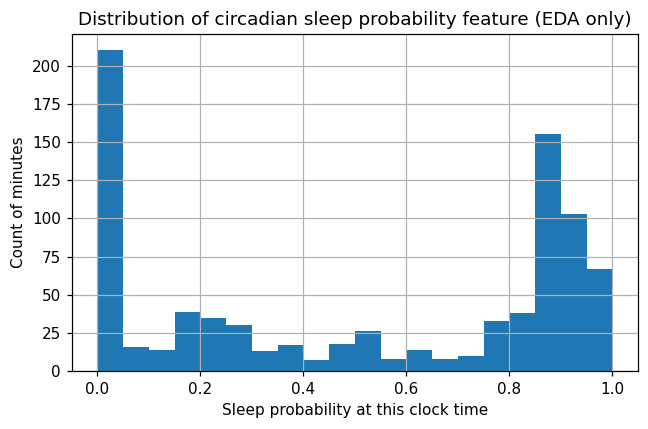

Number of feature columns: 84
'y' in feature_cols?         False
'clock_minute' in features?  False


In [ ]:
win60["clock_minute"] = (
    win60["timestamp"].dt.hour * 60 + win60["timestamp"].dt.minute
).astype("int16")

sleep_prob_clock = (
    win60
    .groupby("clock_minute")["y"]
    .mean()
    .astype("float32")
)

display(sleep_prob_clock.head())

plt.figure(figsize=(6, 4))
sleep_prob_clock.hist(bins=20)
plt.xlabel("Sleep probability at this clock time")
plt.ylabel("Count of minutes")
plt.title("Distribution of circadian sleep probability feature (EDA only)")
plt.tight_layout()
plt.show()

feature_exclude = {"timestamp", "subject_id", "y", "clock_minute"}

feature_cols = [c for c in win60.columns if c not in feature_exclude]

print("Number of feature columns:", len(feature_cols))
print("'y' in feature_cols?        ", "y" in feature_cols)
print("'clock_minute' in features? ", "clock_minute" in feature_cols)

## 8) LOSO Training (SVM-RBF) — Settings, Search, and Runner

We train a subject-independent classifier using **Leave-One-Subject-Out (LOSO)** cross-validation.
- Model: `Pipeline(StandardScaler → SVC(kernel='rbf'))`
- Inner search: **HalvingGridSearchCV** if `USE_HALVING=True`, else **GridSearchCV**
- Speed control: optional class-balanced subsampling per training fold
- Evaluation: per-subject sensitivity, specificity, and macro-F1

In [ ]:
# Settings
RANDOM_STATE = 42
CV_SPLITS = 3
MAX_TRN_PER_FOLD = 120_000   # Subsample cap per subject fold (speed control)
USE_HALVING = True          # Use HalvingGridSearchCV for faster model search

# Parameter grid (balanced search space)
GRID = {
    "svm__C": [0.5, 1, 3, 10, 30],
    "svm__gamma": ["scale", 0.1, 0.03, 0.01, 0.003],
    "svm__class_weight": [
        "balanced",
        {0: 1.2, 1: 1.0},
        {0: 1.4, 1: 1.0},
        {0: 1.6, 1: 1.0},
    ]
}

In [ ]:
# Scoring functions
def _spec(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn / (tn + fp + 1e-9)

def _spec_bias(y_true, y_pred, w_spec=0.7):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    spec = tn / (tn + fp + 1e-9)
    sens = tp / (tp + fn + 1e-9)
    return w_spec * spec + (1.0 - w_spec) * sens

SPEC_BIASED_SCOR = make_scorer(_spec_bias)
BAL_ACC_SCORER = make_scorer(balanced_accuracy_score)

In [ ]:
# Subsampling helper
def _subsample_balanced(X, y, max_n, seed=42):
    """Return up to max_n samples with ~50/50 class balance."""
    if (max_n is None) or (len(y) <= max_n):
        return X, y
    rng = np.random.default_rng(seed)
    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]
    take_pos = min(len(idx_pos), max_n // 2)
    take_neg = min(len(idx_neg), max_n - take_pos)
    sub_idx = np.concatenate([
        rng.choice(idx_pos, take_pos, replace=False),
        rng.choice(idx_neg, take_neg, replace=False)
    ])
    rng.shuffle(sub_idx)
    return X[sub_idx], y[sub_idx]

In [ ]:
# Search helper
def _make_search(pipe, param_grid, cv, refit_key="spec_biased"):
    """Return a searcher compatible with both GridSearchCV and HalvingGridSearchCV."""
    if USE_HALVING:
        # HalvingGridSearchCV only accepts a single scoring callable
        return HalvingGridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            factor=3,
            cv=cv,
            scoring=SPEC_BIASED_SCOR,
            refit=True,
            n_jobs=-1,
            verbose=1
        )
    else:
        # fallback
        return GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            cv=cv,
            scoring={"spec_biased": SPEC_BIASED_SCOR, "bal_acc": BAL_ACC_SCORER, "f1": "f1_macro"},
            refit="spec_biased",
            n_jobs=-1,
            verbose=0
        )

In [ ]:
# LOSO function
def loso_train_predict_svm(df, feat_cols):
    """Leave-One-Subject-Out with RBF-SVM and inner CV per training fold."""
    subjects = sorted(df["subject_id"].unique().tolist())
    per_subj_metrics = {}
    per_subj_preds = []
    per_subj_params = {}

    for i, sid in enumerate(subjects, 1):
        print(f"\n[{i}/{len(subjects)}] Holdout subject: {sid}")
        train = df[df["subject_id"] != sid]
        test = df[df["subject_id"] == sid]

        Xtr = train[feat_cols].values
        ytr = train["y"].values
        Xte = test[feat_cols].values
        yte = test["y"].values

        # Subsample for speed
        Xtr, ytr = _subsample_balanced(Xtr, ytr, MAX_TRN_PER_FOLD, seed=RANDOM_STATE + i)

        pipe = Pipeline([
            ("scaler", StandardScaler(with_mean=True, with_std=True)),
            ("svm", SVC(kernel="rbf",
                        class_weight="balanced",
                        random_state=RANDOM_STATE,
                        cache_size=2000))
        ])

        # Use fast searcher
        search = _make_search(pipe, GRID, cv=CV_SPLITS)
        search.fit(Xtr, ytr)
        best = search.best_estimator_
        per_subj_params[sid] = search.best_params_

        # Predictions
        scores = best.decision_function(Xte)
        yhat = (scores > 0.2).astype(int)  # thresholded to favor wake

        tn, fp, fn, tp = confusion_matrix(yte, yhat, labels=[0, 1]).ravel()
        sens = tp / (tp + fn + 1e-9)
        spec = tn / (tn + fp + 1e-9)
        f1 = f1_score(yte, yhat, average="macro")

        per_subj_metrics[sid] = {
            "sensitivity": sens,
            "specificity": spec,
            "f1_macro": f1
        }

        out = test[["timestamp", "subject_id", "y"]].copy()
        out["y_pred"] = yhat.astype("int8")
        per_subj_preds.append(out)

        del train, test, Xtr, ytr, Xte, yte, yhat, best, search
        gc.collect()

    metrics_df = pd.DataFrame(per_subj_metrics).T.sort_index()
    preds_df = pd.concat(per_subj_preds, ignore_index=True)

    return metrics_df, preds_df, per_subj_params

## 9) Run LOSO + inspect results

We compute mean metrics, show first few per-subject rows, and list the best params picked per subject.

In [ ]:
metrics_loso, preds_loso, params_loso = loso_train_predict_svm(win60, feature_cols)


[1/29] Holdout subject: PSGO_01
n_iterations: 5
n_required_iterations: 5
n_possible_iterations: 5
min_resources_: 402
max_resources_: 32592
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 100
n_resources: 402
Fitting 3 folds for each of 100 candidates, totalling 300 fits
----------
iter: 1
n_candidates: 34
n_resources: 1206
Fitting 3 folds for each of 34 candidates, totalling 102 fits
----------
iter: 2
n_candidates: 12
n_resources: 3618
Fitting 3 folds for each of 12 candidates, totalling 36 fits
----------
iter: 3
n_candidates: 4
n_resources: 10854
Fitting 3 folds for each of 4 candidates, totalling 12 fits
----------
iter: 4
n_candidates: 2
n_resources: 32562
Fitting 3 folds for each of 2 candidates, totalling 6 fits

[2/29] Holdout subject: PSGO_02
n_iterations: 5
n_required_iterations: 5
n_possible_iterations: 5
min_resources_: 405
max_resources_: 32854
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 100
n_resources: 405
Fitting 3

## CONDITIONAL: Reload previous LOSO outputs
Use results saved to Drive so we can summarize and plot without rerunning the model.

In [ ]:
BASE_DIR = ROOT / "results_loso_baseline"
FINAL_DIR = ROOT / "results_loso_final_threshold"

# Baseline results
metrics_loso = pd.read_csv(BASE_DIR / "metrics_per_subject.csv", index_col=0)
params_loso = pd.read_csv(BASE_DIR / "svm_params_per_subject.csv", index_col=0)
preds_loso = pd.read_parquet(BASE_DIR / "preds_per_minute.parquet")

# Final tuned results
per_subj = pd.read_csv(FINAL_DIR / "per_subject_final.csv", index_col=0)
thr_table = pd.read_csv(FINAL_DIR / "threshold_sweep.csv")
preds_final = pd.read_parquet(FINAL_DIR / "preds_final.parquet")


Mean metrics across subjects:


,sensitivity,specificity,f1_macro
mean,0.765381,0.737895,0.716229



Per-subject metrics (first 10):


,sensitivity,specificity,f1_macro
PSGO_01,0.415479,0.848921,0.501828
PSGO_02,0.924157,0.419580,0.689255
PSGO_03,0.921615,0.416667,0.661580
PSGO_05,0.953297,0.653696,0.813840
PSGO_06,0.945205,0.462121,0.729643
PSGO_07,0.743802,0.947761,0.752902
PSGO_08,0.633416,0.605882,0.597039
PSGO_09,0.916262,0.943503,0.913385
PSGO_10,0.863760,0.901734,0.863821
PSGO_11,0.682927,0.880342,0.692013



Best SVM params per subject (first 10):


...

,sensitivity,specificity,f1_macro
PSGO_28,0.132832,0.886228,0.336430
PSG_24,0.406818,0.855491,0.532246
PSGO_01,0.415479,0.848921,0.501828
PSGO_27,0.519608,0.632353,0.531632
PSGO_17,0.589391,0.394366,0.443022



Top 5 by specificity:


,sensitivity,specificity,f1_macro
PSG_19,0.739726,0.987342,0.788570
PSGO_07,0.743802,0.947761,0.752902
PSGO_09,0.916262,0.943503,0.913385
PSG_14,0.969543,0.939086,0.954315
PSG_29,0.625348,0.916201,0.765689



Bottom 5 by specificity:


,sensitivity,specificity,f1_macro
PSGO_17,0.589391,0.394366,0.443022
PSGO_03,0.921615,0.416667,0.661580
PSGO_02,0.924157,0.419580,0.689255
PSGO_12,0.862319,0.446667,0.663370
PSGO_06,0.945205,0.462121,0.729643


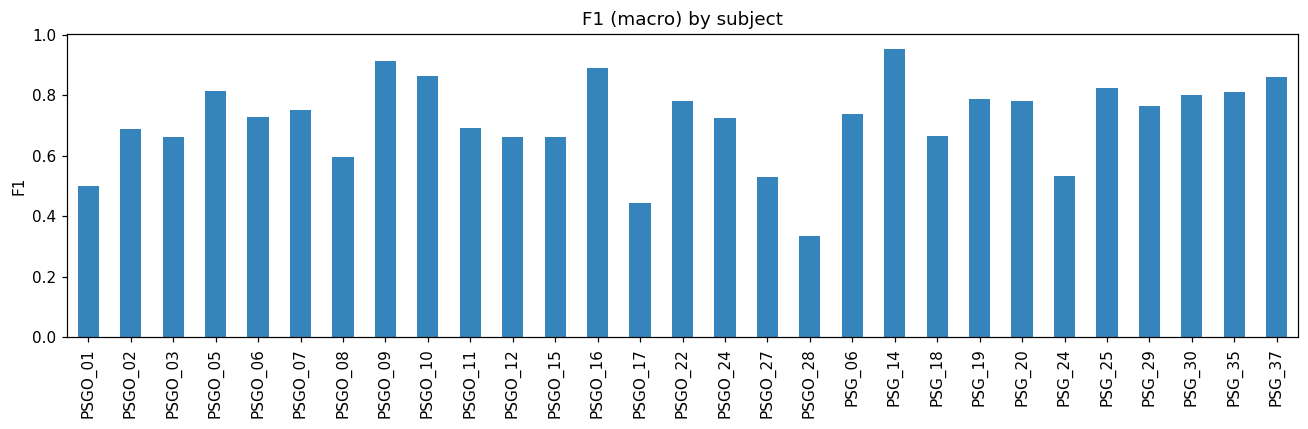

<Figure size 1320x440 with 0 Axes>

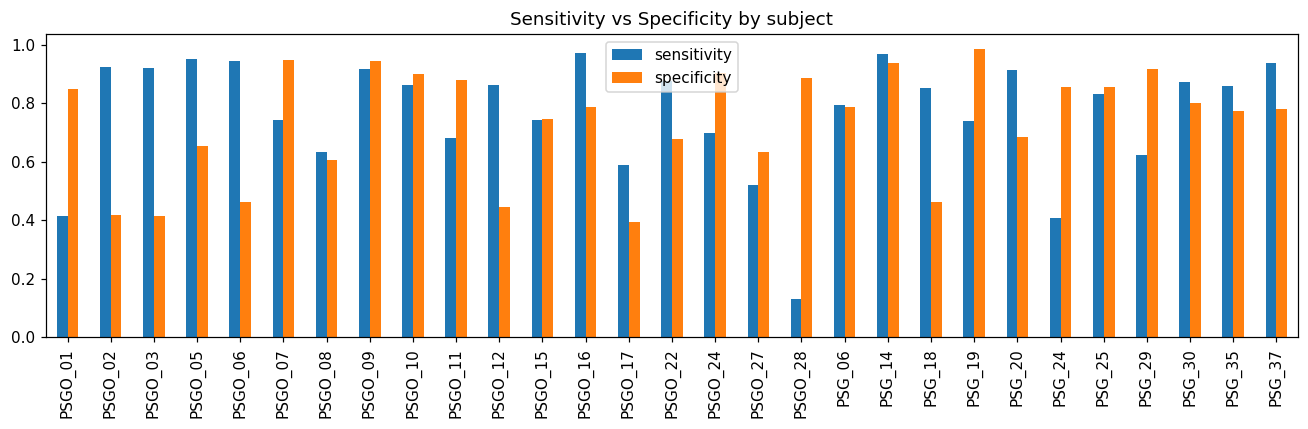

In [ ]:
print("\nMean metrics across subjects:")
display(metrics_loso.mean().to_frame("mean").T)

print("\nPer-subject metrics (first 10):")
display(metrics_loso.head(10))

print("\nBest SVM params per subject (first 10):")
display(pd.DataFrame(params_loso).T.head(10))

# Small bar charts
def top_bottom(df, col, k=5):
    print(f"\nTop {k} by {col}:")
    display(df.sort_values(col, ascending=False).head(k))
    print(f"\nBottom {k} by {col}:")
    display(df.sort_values(col, ascending=True).head(k))

top_bottom(metrics_loso, "f1_macro", 5)
top_bottom(metrics_loso, "sensitivity", 5)
top_bottom(metrics_loso, "specificity", 5)

plt.figure(figsize=(12,4))
metrics_loso.sort_index()["f1_macro"].plot(kind="bar", alpha=.9)
plt.title("F1 (macro) by subject")
plt.ylabel("F1")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
metrics_loso.sort_index()[["sensitivity","specificity"]].plot(kind="bar", figsize=(12,4))
plt.title("Sensitivity vs Specificity by subject")
plt.tight_layout()
plt.show()

## 10) Save baseline results (tables + minute-level predictions)

We save:
- `metrics_per_subject.csv`
- `preds_per_minute.parquet` (has `score` for threshold sweep)
- `svm_params_per_subject.csv`

In [ ]:
OUT = ROOT / "results_loso_baseline"
OUT.mkdir(exist_ok=True)

metrics_loso.to_csv(OUT / "metrics_per_subject.csv")
preds_loso.to_parquet(OUT / "preds_per_minute.parquet", index=False)
pd.DataFrame(params_loso).T.to_csv(OUT / "svm_params_per_subject.csv")

print("Saved to:", OUT)

Saved to: /content/drive/MyDrive/dualsleep/results_loso_baseline


## 11) Optimize Decision Threshold for Balanced Performance
We adjust the global threshold on the SVM’s decision scores (`preds_loso["score"]`)
to find the best trade-off between **sensitivity** (sleep detection) and **specificity** (wake detection).
The optimal threshold maximizes **balanced accuracy**, ensuring robust overall performance.

NOTE: 'score' not found; using a fallback derived from y_pred.
Top thresholds by balanced accuracy (ties -> higher specificity):


,thr,sensitivity,specificity,f1_macro,bal_acc
0,-0.600,0.761305,0.763116,0.737172,0.762211
1,-0.575,0.761305,0.763116,0.737172,0.762211
2,-0.550,0.761305,0.763116,0.737172,0.762211
3,-0.525,0.761305,0.763116,0.737172,0.762211
4,-0.500,0.761305,0.763116,0.737172,0.762211
5,-0.475,0.761305,0.763116,0.737172,0.762211
6,-0.450,0.761305,0.763116,0.737172,0.762211
7,-0.425,0.761305,0.763116,0.737172,0.762211
8,-0.400,0.761305,0.763116,0.737172,0.762211
9,-0.375,0.761305,0.763116,0.737172,0.762211



Wake–favoring (high specificity) candidate:


,thr,sensitivity,specificity,f1_macro,bal_acc,spec_minus_sens
0,-0.6,0.761305,0.763116,0.737172,0.762211,0.001811


Using FINAL_THR = -0.600

FINAL threshold = -0.600
sensitivity=0.761  specificity=0.763  f1_macro=0.737  bal_acc=0.762

Classification report:
               precision    recall  f1-score   support

        wake       0.58      0.76      0.66     10102
       sleep       0.88      0.76      0.82     23750

    accuracy                           0.76     33852
   macro avg       0.73      0.76      0.74     33852
weighted avg       0.79      0.76      0.77     33852


Top subjects by f1_macro (post-threshold):


,sensitivity,specificity,f1_macro
subject_id,,,
PSG_14,0.969543,0.939086,0.954315
PSGO_09,0.916262,0.943503,0.929882
PSGO_10,0.863760,0.901734,0.882747
PSGO_16,0.972752,0.786611,0.879681
PSG_19,0.739726,0.987342,0.863534
PSG_37,0.936709,0.779310,0.858010
PSGO_07,0.743802,0.947761,0.845781
PSG_25,0.831126,0.855769,0.843448



Bottom subjects by f1_macro (post-threshold):


,sensitivity,specificity,f1_macro
subject_id,,,
PSGO_17,0.589391,0.394366,0.491879
PSGO_28,0.132832,0.886228,0.509530
PSGO_27,0.519608,0.632353,0.575980
PSGO_08,0.633416,0.605882,0.619649
PSG_24,0.406818,0.855491,0.631155


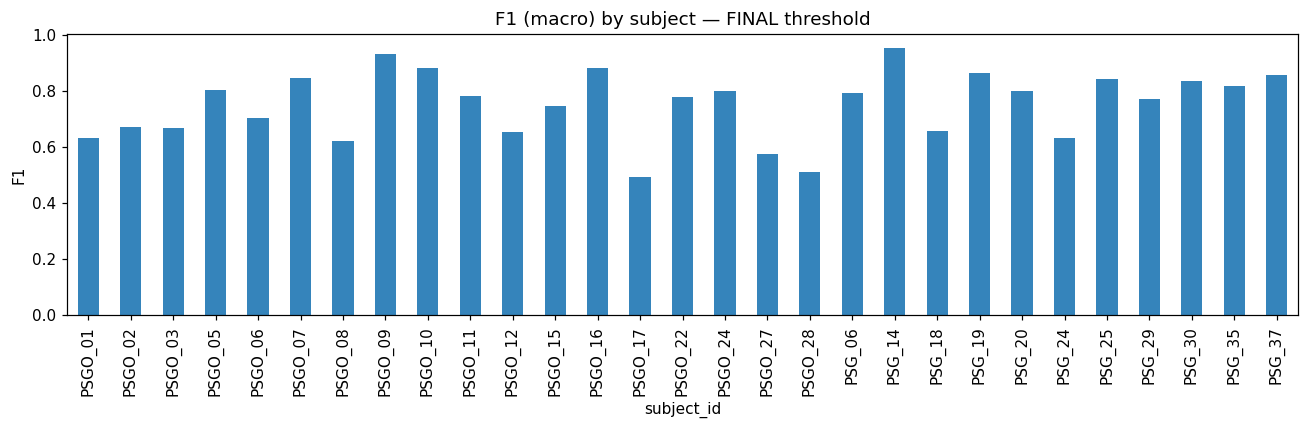

<Figure size 1320x440 with 0 Axes>

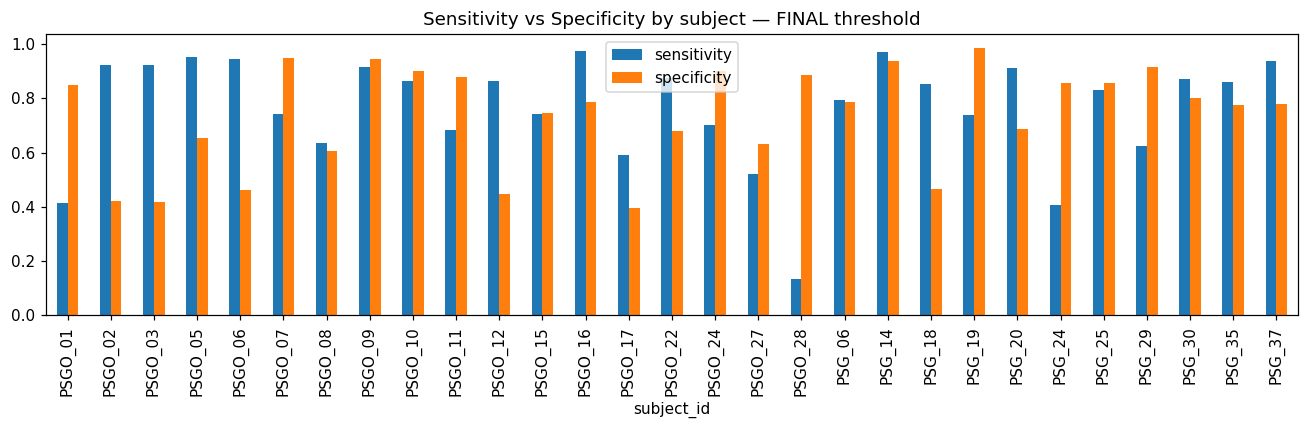

In [ ]:
# If reloaded from disk without 'score', derive a fallback from y_pred (coarse).
if "score" not in preds_loso.columns:
    preds_loso["score"] = preds_loso["y_pred"].replace({0:-1, 1:1}).astype(float)
    print("NOTE: 'score' not found; using a fallback derived from y_pred.")

def metrics_at_thresh(df, thr):
    y_true = df["y"].values
    y_hat  = (df["score"].values > thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_hat, labels=[0,1]).ravel()
    sens = tp / (tp + fn + 1e-9)
    spec = tn / (tn + fp + 1e-9)
    f1   = f1_score(y_true, y_hat, average="macro")
    bal  = balanced_accuracy_score(y_true, y_hat)
    return sens, spec, f1, bal

# sweep around a good range/resolution
ths = np.linspace(-0.6, 0.6, 49)

rows = []
for t in ths:
    sens, spec, f1, bal = metrics_at_thresh(preds_loso, t)
    rows.append({"thr": t, "sensitivity": sens, "specificity": spec, "f1_macro": f1, "bal_acc": bal})
thr_table = pd.DataFrame(rows)

print("Top thresholds by balanced accuracy (ties -> higher specificity):")
best_idx = thr_table.sort_values(["bal_acc","specificity"], ascending=False).index[0]
best = thr_table.loc[best_idx]
display(thr_table.sort_values(["bal_acc","specificity"], ascending=False).head(10))

# a wake-favoring pick (higher specificity)
best_constrained = (thr_table.assign(spec_minus_sens=lambda d: d["specificity"]-d["sensitivity"])
                    .sort_values(["spec_minus_sens","bal_acc"], ascending=False).head(1))
print("\nWake–favoring (high specificity) candidate:")
display(best_constrained)

# Lock final threshold (choose 'best' or 'best_constrained.iloc[0]')
FINAL_THR = float(best["thr"])
print(f"Using FINAL_THR = {FINAL_THR:.3f}")

# Recompute everything with the final threshold
preds_final = preds_loso.copy()
preds_final["y_pred"] = (preds_final["score"] > FINAL_THR).astype("int8")

tn, fp, fn, tp = confusion_matrix(preds_final["y"], preds_final["y_pred"], labels=[0,1]).ravel()
sens = tp / (tp + fn + 1e-9)
spec = tn / (tn + fp + 1e-9)
f1   = f1_score(preds_final["y"], preds_final["y_pred"], average="macro")
bal  = balanced_accuracy_score(preds_final["y"], preds_final["y_pred"])

print(f"\nFINAL threshold = {FINAL_THR:.3f}")
print(f"sensitivity={sens:.3f}  specificity={spec:.3f}  f1_macro={f1:.3f}  bal_acc={bal:.3f}")
print("\nClassification report:\n",
      classification_report(preds_final["y"], preds_final["y_pred"], target_names=["wake","sleep"]))

# Per-subject summary
per_subj = (preds_final
            .groupby("subject_id")[["y","y_pred"]]
            .apply(lambda d: pd.Series({
                "sensitivity": ( (d["y"]==1) & (d["y_pred"]==1) ).sum() / ((d["y"]==1).sum() + 1e-9),
                "specificity": ( (d["y"]==0) & (d["y_pred"]==0) ).sum() / ((d["y"]==0).sum() + 1e-9),
            })))
per_subj["f1_macro"] = per_subj.mean(axis=1)  # quick proxy for ranking on a slide

print("\nTop subjects by f1_macro (post-threshold):")
display(per_subj.sort_values("f1_macro", ascending=False).head(8))
print("\nBottom subjects by f1_macro (post-threshold):")
display(per_subj.sort_values("f1_macro", ascending=True).head(5))

# Plots (post-threshold)
plt.figure(figsize=(12,4))
per_subj.sort_index()["f1_macro"].plot(kind="bar", alpha=.9)
plt.title("F1 (macro) by subject — FINAL threshold")
plt.ylabel("F1")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
per_subj.sort_index()[["sensitivity","specificity"]].plot(kind="bar", figsize=(12,4))
plt.title("Sensitivity vs Specificity by subject — FINAL threshold")
plt.tight_layout()
plt.show()

In [ ]:
# Save final results
OUT_FINAL = ROOT / "results_loso_final_threshold"
OUT_FINAL.mkdir(exist_ok=True)
per_subj.to_csv(OUT_FINAL / "per_subject_final.csv")
preds_final.to_parquet(OUT_FINAL / "preds_final.parquet", index=False)
thr_table.to_csv(OUT_FINAL / "threshold_sweep.csv", index=False)

print("Saved final results to:", OUT_FINAL)

Saved final results to: /content/drive/MyDrive/dualsleep/results_loso_final_threshold


## 12) Subject timeline (first N hours)

Visual check of true vs predicted sleep/wake for a subject.

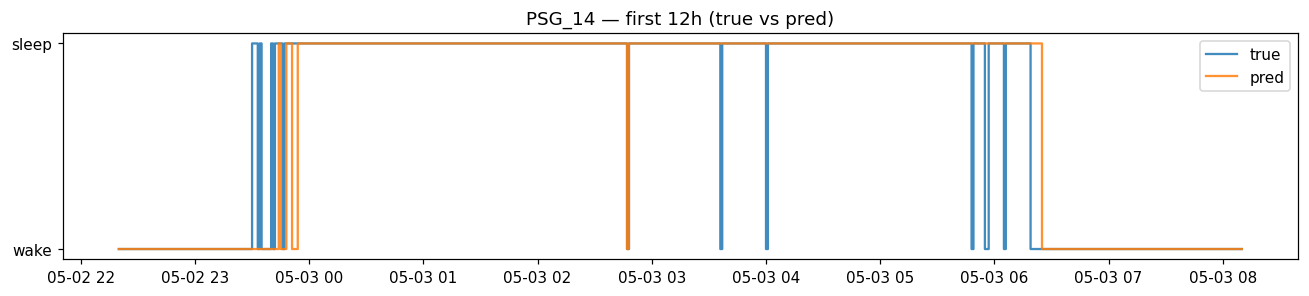

In [ ]:
def plot_subject_timeline(df_preds, sid, hrs):
    d = df_preds[df_preds["subject_id"]==sid].sort_values("timestamp").copy()
    end = d["timestamp"].min() + pd.Timedelta(hours=hrs)
    d = d[d["timestamp"]<=end]

    plt.figure(figsize=(12,2.8))
    plt.plot(d["timestamp"], d["y"], drawstyle="steps-post", label="true", alpha=.85)
    plt.plot(d["timestamp"], d["y_pred"], drawstyle="steps-post", label="pred", alpha=.85)
    plt.yticks([0,1], ["wake","sleep"])
    plt.legend()
    plt.title(f"{sid} — first {hrs}h (true vs pred)")
    plt.tight_layout()
    plt.show()

plot_subject_timeline(preds_final, "PSG_14", hrs=12)

In [ ]:
import joblib

X_all = win60[feature_cols].values
y_all = win60["y"].values

print("X_all shape:", X_all.shape)
print("y_all shape:", y_all.shape)

FINAL_SVM_PARAMS = {
    "C": 10.0,
    "gamma": 0.01,
    "class_weight": "balanced",
}

final_model = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("svm", SVC(
        kernel="rbf",
        C=FINAL_SVM_PARAMS["C"],
        gamma=FINAL_SVM_PARAMS["gamma"],
        class_weight=FINAL_SVM_PARAMS["class_weight"],
        random_state=RANDOM_STATE,
        cache_size=2000,
    )),
])

print("Fitting final SVM on full dataset...")
final_model.fit(X_all, y_all)
print("Done fitting.")

bundle = {
    "model": final_model,
    "feature_cols": feature_cols,
    "svm_params": FINAL_SVM_PARAMS,
}

joblib_path = "dualsleep_svm.joblib"
joblib.dump(bundle, joblib_path)

print(f"Saved deployment bundle to: {joblib_path}")

X_all shape: (33852, 84)
y_all shape: (33852,)
Fitting final SVM on full dataset...
Done fitting.
Saved deployment bundle to: dualsleep_svm.joblib


In [ ]:
bundle = joblib.load("dualsleep_svm.joblib")

model = bundle["model"]
saved_feature_cols = bundle["feature_cols"]
saved_params = bundle["svm_params"]

print("Loaded model with", len(saved_feature_cols), "features")
print("Saved SVM params:", saved_params)

print("Feature list same as current?", set(saved_feature_cols) == set(feature_cols))

sample = win60.iloc[:10].copy()
X_sample = sample[saved_feature_cols]
y_sample_true = sample["y"].values

y_sample_pred = model.predict(X_sample)
sample["y_pred"] = y_sample_pred

print("\nSample predictions (first 10 rows):")
display(sample[["timestamp", "subject_id", "y", "y_pred"]])

X_all = win60[saved_feature_cols].values
y_all = win60["y"].values

y_all_pred = model.predict(X_all)

print("\nClassification report on full data (saved model):")
print(classification_report(
    y_all, y_all_pred,
    target_names=["wake", "sleep"],
    digits=3
))

Loaded model with 84 features
Saved SVM params: {'C': 10.0, 'gamma': 0.01, 'class_weight': 'balanced'}
Feature list same as current? True

Sample predictions (first 10 rows):


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


,timestamp,subject_id,y,y_pred
0,2018-08-31 19:57:00,PSGO_01,0,0
1,2018-08-31 19:58:00,PSGO_01,0,0
2,2018-08-31 19:59:00,PSGO_01,0,0
3,2018-08-31 20:00:00,PSGO_01,0,0
4,2018-08-31 20:01:00,PSGO_01,0,0
5,2018-08-31 20:02:00,PSGO_01,0,0
6,2018-08-31 20:03:00,PSGO_01,0,0
7,2018-08-31 20:04:00,PSGO_01,0,0
8,2018-08-31 20:05:00,PSGO_01,0,0
9,2018-08-31 20:06:00,PSGO_01,0,0



Classification report on full data (saved model):
              precision    recall  f1-score   support

        wake      0.966     0.958     0.962     10102
       sleep      0.982     0.986     0.984     23750

    accuracy                          0.977     33852
   macro avg      0.974     0.972     0.973     33852
weighted avg      0.977     0.977     0.977     33852

